# Глава 4

## Задание 4.1

In [1]:
from thinkdsp import read_wave, decorate


sound_file = 'car_sound.wav'
wave = read_wave(sound_file)
wave.make_audio()




In [2]:
segment = wave.segment(start=10, duration=1.0)
segment.make_audio()

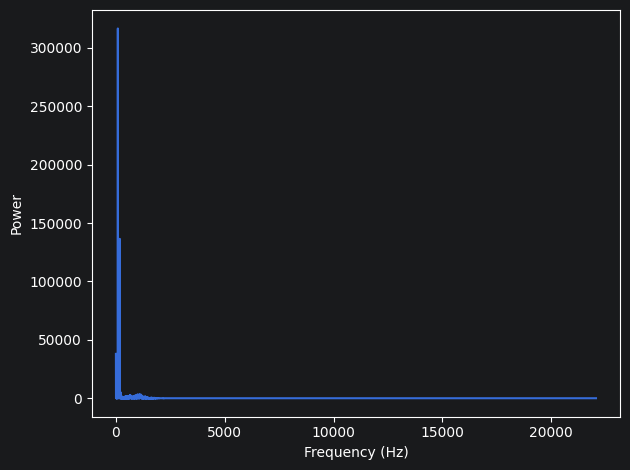

In [3]:
spectrum = segment.make_spectrum()
spectrum.plot_power()
decorate(xlabel="Frequency (Hz)", ylabel="Power")

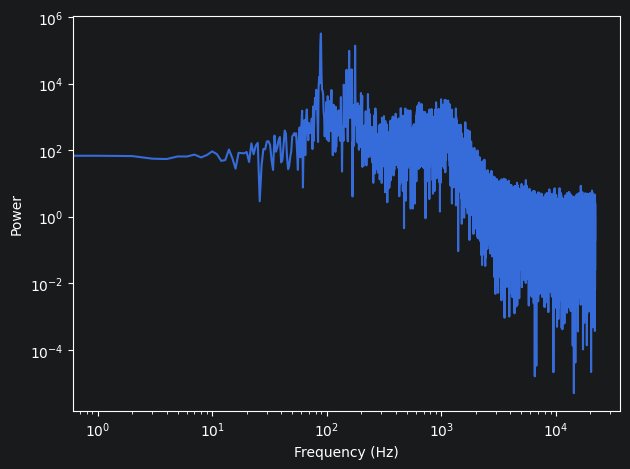

In [4]:
spectrum.plot_power()

loglog = dict(xscale="log", yscale="log")
decorate(xlabel="Frequency (Hz)", ylabel="Power", **loglog)

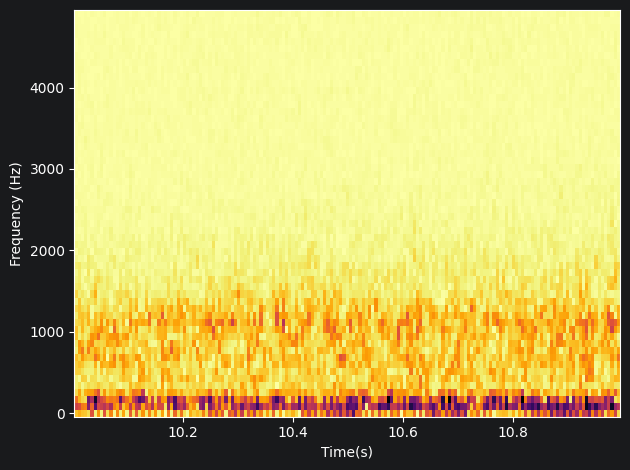

In [5]:
segment.make_spectrogram(512).plot(high=5000)
decorate(xlabel="Time(s)", ylabel="Frequency (Hz)")

## Задание 4.2

In [6]:
from thinkdsp import Spectrum

def bartlett_method(wave, seg_length=512, win_flag=True):
    spectrogram = wave.make_spectrogram(seg_length, win_flag)
    spectrums = spectrogram.spec_map.values()

    psds = [spectrum.power for spectrum in spectrums]

    hs = np.sqrt(sum(psds) / len(psds))
    fs = next(iter(spectrums)).fs

    spectrum = Spectrum(hs, fs, wave.framerate)
    return spectrum



## Задание 4.3


In [10]:
import pandas as pd
df = pd.read_csv("BTC_USD_2013-10-01_2020-03-26-CoinDesk.csv", parse_dates=[0])
df

,Currency,Date,Closing Price (USD),24h Open (USD),24h High (USD),24h Low (USD)
0,BTC,2013-10-01,123.654990,124.304660,124.751660,122.563490
1,BTC,2013-10-02,125.455000,123.654990,125.758500,123.633830
2,BTC,2013-10-03,108.584830,125.455000,125.665660,83.328330
3,BTC,2013-10-04,118.674660,108.584830,118.675000,107.058160
4,BTC,2013-10-05,121.338660,118.674660,121.936330,118.005660
...,...,...,...,...,...,...
2354,BTC,2020-03-22,5884.340133,6187.042146,6431.873162,5802.553402
2355,BTC,2020-03-23,6455.454688,5829.352511,6620.858253,5694.198299
2356,BTC,2020-03-24,6784.318011,6455.450650,6863.602196,6406.037439
2357,BTC,2020-03-25,6706.985089,6784.325204,6981.720386,6488.111885


In [11]:
ys = df["Closing Price (USD)"]
ts = df.index

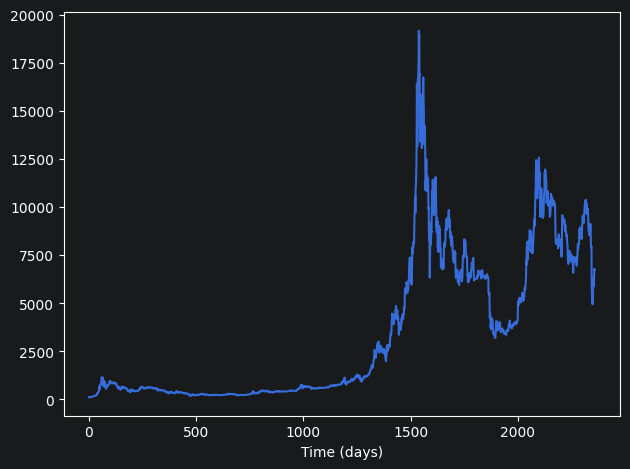

In [13]:
from thinkdsp import Wave
wave = Wave(ys, ts, framerate=1)
wave.plot()
decorate(xlabel="Time (days)")

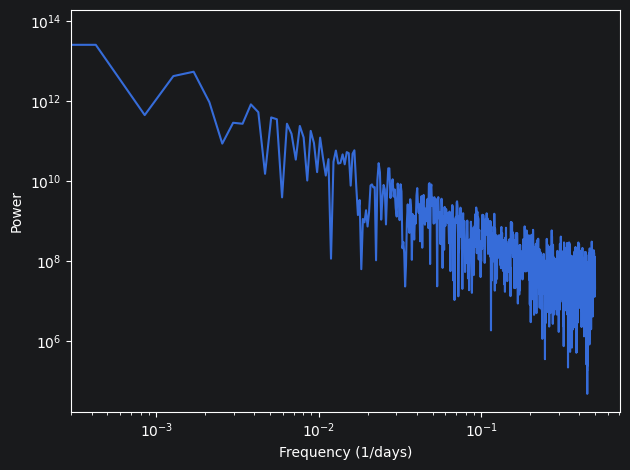

In [14]:
spectrum = wave.make_spectrum()
spectrum.plot_power()
decorate(xlabel="Frequency (1/days)", ylabel="Power", **loglog)

## Задание 4.4

In [16]:
from thinkdsp import Noise
import numpy as np


class UncorrelatedPoissonNoise(Noise):

    def evaluate(self, ts):
        ys = np.random.poisson(self.amp, len(ts))
        return ys

In [17]:
amp = 0.001
framerate = 10000
duration = 1

signal = UncorrelatedPoissonNoise(amp=amp)
wave = signal.make_wave(duration=duration, framerate=framerate)
wave.make_audio()

10.0 10


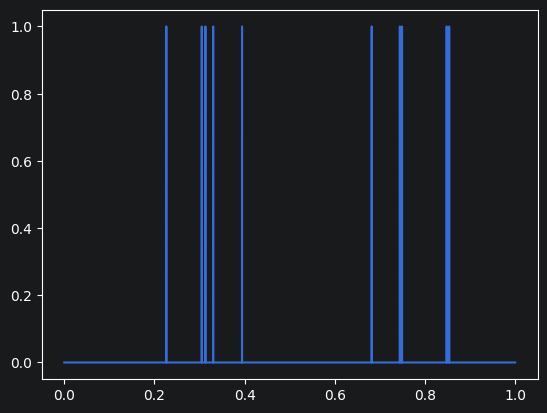

In [18]:
expected = amp * framerate * duration
actual = sum(wave.ys)
print(expected, actual)
wave.plot()

## Задание 4.5

In [ ]:
import numpy as np
from thinkdsp import Wave, decorate

def voss_mccartney_simple(nrows, ncols=16):
    array = np.zeros((nrows, ncols))
    array[0, :] = np.random.random(ncols)
    array[:, 0] = np.random.random(nrows)

    for i in range(nrows - 1):
        for j in range(1, ncols):
            if np.random.random() < 0.5:
                array[i+1, j] = np.random.random()
            else:
                array[i+1, j] = array[i, j]

    total = np.sum(array, axis=1)
    total = total - np.mean(total)
    total = total / np.max(np.abs(total))
    return total

framerate = 11025
duration = 2
n_samples = int(duration * framerate)

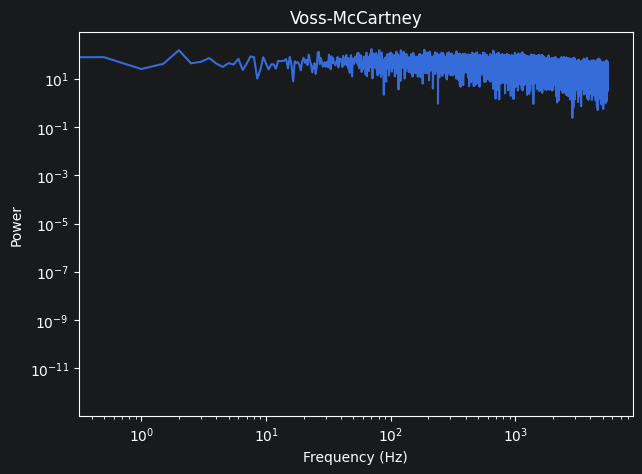

In [29]:


ys = voss_mccartney_simple(n_samples, ncols=16)
wave = Wave(ys, framerate=framerate)

spectrum = wave.make_spectrum()
spectrum.plot()
decorate(xlabel='Frequency (Hz)', ylabel='Power', title='Voss-McCartney')
plt.xscale('log')
plt.yscale('log')
plt.show()

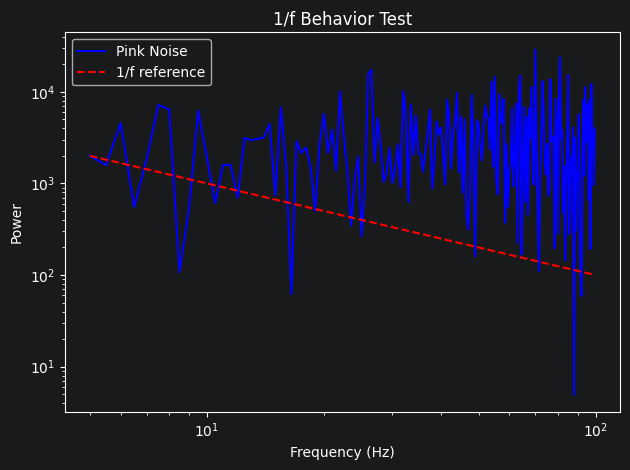

In [30]:
freqs = spectrum.fs[10:200]
power = spectrum.power[10:200]
plt.loglog(freqs, power, 'b-', label='Pink Noise')
plt.loglog(freqs, 1/freqs * power[0]*freqs[0], 'r--', label='1/f reference')
decorate(xlabel='Frequency (Hz)', ylabel='Power', title='1/f Behavior Test')
plt.legend()
plt.show()
